In [9]:
import pandas as pd
df_origin = pd.read_csv(
    "comptages-routiers-permanents.csv", 
    #encoding = "latin-1",
    #nrows=10, 
    usecols=["Identifiant arc", "Date et heure de comptage", "Débit horaire","Taux d'occupation","Libelle", "geo_point_2d"],
    sep=';'
)
df_select = df_origin.head(30000)
df_select.head()


,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,geo_point_2d
0,5325,PE_Reuilly,2024-10-04T21:00:00+02:00,5955.0,18.70000,"48.83194119399435, 2.4051573651790856"
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03T14:00:00+01:00,NaN,24.60056,"48.815888020936654, 2.3587275983847618"
2,4010,Av_de_Clichy,2024-12-04T14:00:00+01:00,223.0,13.72667,"48.89143424973461, 2.3188079239898496"
3,1067,Quai_d'Issy,2025-01-11T19:00:00+01:00,769.0,4.43000,"48.839727155124635, 2.2702033361716216"
4,5460,SI_Passy,2025-02-18T22:00:00+01:00,NaN,NaN,"48.85791852282797, 2.26121220748304"


In [10]:
import pandas as pd
root = r"F:\G2\ENPC\3A1\MCNDU\autoroute\\"
df_select = pd.read_csv(
    root + "all_flags_merged.csv",
    sep=','
)
df_select.head()


,Taux d'occupation,Débit horaire,Arc Name,Arc ID,Date et heure de comptage,Trafic,Latitude,Longitude
0,27.07056,242.0,Chapelle,1648,2026-01-05 15:00:00+00:00,Pré-saturé,48.897784,2.359253
1,8.80000,2627.0,PI_Chapelle_Est,5378,2026-01-05 15:00:00+00:00,Fluide,48.900719,2.362259
2,5.67889,280.0,Chapelle,1649,2026-01-05 15:00:00+00:00,Fluide,48.897779,2.358958
3,7.85000,2623.0,PI_Chapelle_Ouest,5377,2026-01-05 15:00:00+00:00,Fluide,48.900818,2.358403
4,19.15000,3031.0,PE_Chapelle_Ouest,5376,2026-01-05 15:00:00+00:00,Pré-saturé,48.900978,2.358405


我们需要分析的包括：
是周几
是否是法国的公共假日或大型活动
是哪个月
是否是周末
是否是学生假日
是否是假日前（包括周末）
是否是假日后（包括周末）
属于哪个季节

Les facteurs que nous devons analyser sont les suivants :
Le jour de la semaine
S'il s'agit d'un jour férié français ou d'un événement majeur
Est-ce un jour férié scolaire ?
Le mois
S'il s'agit d'un week-end
S'il s'agit d'une période précédant un jour férié (week-ends compris)
S'il s'agit d'une période suivant un jour férié (week-ends compris)
La saison

In [11]:
import holidays

# 法国公共假日 jour fériés en France
fr_holidays = holidays.France()
print(fr_holidays)

{'country': FR, 'expand': True, 'language': None, 'market': None, 'observed': True, 'subdiv': None, 'years': set()}


In [12]:
import pandas as pd

MAJOR_EVENTS_PARIS_2025 = {
    "paris_marathon_2025": {"start": "2025-04-06", "end": "2025-04-06"},
    "paris_marathon_2026": {"start": "2026-04-12", "end": "2026-04-12"},
    "french_open": {
        "start": "2025-05-25",
        "end": "2025-06-08"
    },
    "fete_musique": {
        "start": "2025-06-21",
        "end": "2025-06-21"
    },
    "tour_de_france_final": {
        "start": "2025-07-27",
        "end": "2025-07-27"
    }
}

school_holidays_zone_c = [
    ("2024-10-19", "2024-11-03"),
    ("2024-12-21", "2025-01-05"),
    # Vacances d'hiver
    ("2025-02-15", "2025-03-02"),
    # Vacances de printemps
    ("2025-04-12", "2025-04-27"),
    # Vacances d'été
    ("2025-07-05", "2025-08-31"),
    # Vacances de la Toussaint
    ("2025-10-18", "2025-11-02"),
    # Vacances de Noël
    ("2025-12-20", "2026-01-04"),
    ("2026-02-21", "2026-03-08")
]


In [13]:
import pandas as pd
df = df_select.copy()
#确保格式  Vérifiez le format
df['Date et heure de comptage'] = pd.to_datetime(
    df['Date et heure de comptage'],
    errors='coerce',  # 遇到无法解析的变成 NaT
    utc=True           # 带时区时间统一转 UTC
)
#获取日期  Date d'acquisition
n_before = len(df)
df = df.dropna(subset=['Date et heure de comptage']).copy()
n_after = len(df)
df["date"] = df["Date et heure de comptage"].dt.date
print(f"Nombre de lignes avant suppression: {n_before}")
print(f"Nombre de lignes supprimées: {n_after}")
# 判断是否公共假日  Vérifiez si c'est un jour férié
df["est_jour_ferie"] = df["date"].apply( lambda d: 1 if d in fr_holidays else 0
)

# 判断是否是大型活动日 Vérifiez s'il s'agit d'un jour d'événement majeur
def is_major_event(date, events):
    for event, period in events.items():
        start = pd.to_datetime(period["start"]).date()
        end = pd.to_datetime(period["end"]).date()
        if start <= date <= end:
            return 1
    return 0
df["est_evenement_majeur"] = df["date"].apply(
    lambda d: is_major_event(d, MAJOR_EVENTS_PARIS_2025)
)
print("Calcul des indicateurs temporels 1 terminé.")
# 判断是否是学生假日 Vérifiez s'il s'agit de vacances scolaires
def is_school_holiday(date, holidays):
    for start_str, end_str in holidays:
        start = pd.to_datetime(start_str).date()
        end = pd.to_datetime(end_str).date()
        if start <= date <= end:
            return 1
    return 0
df['est_vacances_scolaires'] = df['date'].apply(
    lambda d: is_school_holiday(d, school_holidays_zone_c)
)
print("Calcul des indicateurs temporels 2 terminé.")
#判断是否是周末 Vérifiez si c'est weekend
df["est_weekend"] = df["Date et heure de comptage"].dt.weekday >= 5

#判断是否是（假期或大型活动日或周末）的前后一天
df["date"] = df["Date et heure de comptage"].dt.floor('D')  # datetime64[ns]
#Vérifiez s'il s'agit du jour avant ou après (jour férié, événement majeur ou week-end)
def generate_day_before_after(df, column_name):
    event_dates = df.loc[df[column_name] == 1, 'date'].drop_duplicates().sort_values()
    
    if event_dates.empty:
        df[f'{column_name}_day_before'] = 0
        df[f'{column_name}_day_after'] = 0
        return
    event_dates_set = set(event_dates)  # Timestamp set
    day_before_dates = set(event_dates - pd.Timedelta(days=1)) - event_dates_set
    day_after_dates  = set(event_dates + pd.Timedelta(days=1)) - event_dates_set

    df[f'{column_name}_day_before'] = df['date'].isin(day_before_dates).astype(int)
    df[f'{column_name}_day_after']  = df['date'].isin(day_after_dates).astype(int)

generate_day_before_after(df, 'est_weekend')
generate_day_before_after(df, 'est_jour_ferie')
generate_day_before_after(df, 'est_evenement_majeur')
generate_day_before_after(df, 'est_vacances_scolaires')

#获取周几，月份以及季节特征 Récupérer le jour de la semaine, le mois et les caractéristiques saisonnières
df["weekday"] = df["Date et heure de comptage"].dt.weekday
df["mois"] = df["Date et heure de comptage"].dt.month
def get_saison(month):
    if month in [12, 1, 2]:
        return "hiver"
    elif month in [3, 4, 5]:
        return "printemps"
    elif month in [6, 7, 8]:
        return "été"
    else:
        return "automne"

df["saison"] = df["mois"].apply(get_saison)

Nombre de lignes avant suppression: 509029
Nombre de lignes supprimées: 509029


In [14]:

df.head()

,Taux d'occupation,Débit horaire,Arc Name,Arc ID,Date et heure de comptage,Trafic,Latitude,Longitude,date,est_jour_ferie,...,est_weekend_day_after,est_jour_ferie_day_before,est_jour_ferie_day_after,est_evenement_majeur_day_before,est_evenement_majeur_day_after,est_vacances_scolaires_day_before,est_vacances_scolaires_day_after,weekday,mois,saison
0,27.07056,242.0,Chapelle,1648,2026-01-05 15:00:00+00:00,Pré-saturé,48.897784,2.359253,2026-01-05 00:00:00+00:00,0,...,1,0,0,0,0,0,1,0,1,hiver
1,8.80000,2627.0,PI_Chapelle_Est,5378,2026-01-05 15:00:00+00:00,Fluide,48.900719,2.362259,2026-01-05 00:00:00+00:00,0,...,1,0,0,0,0,0,1,0,1,hiver
2,5.67889,280.0,Chapelle,1649,2026-01-05 15:00:00+00:00,Fluide,48.897779,2.358958,2026-01-05 00:00:00+00:00,0,...,1,0,0,0,0,0,1,0,1,hiver
3,7.85000,2623.0,PI_Chapelle_Ouest,5377,2026-01-05 15:00:00+00:00,Fluide,48.900818,2.358403,2026-01-05 00:00:00+00:00,0,...,1,0,0,0,0,0,1,0,1,hiver
4,19.15000,3031.0,PE_Chapelle_Ouest,5376,2026-01-05 15:00:00+00:00,Pré-saturé,48.900978,2.358405,2026-01-05 00:00:00+00:00,0,...,1,0,0,0,0,0,1,0,1,hiver


In [15]:
summary_weekend = (
    df
    .groupby('est_weekend')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_weekend


,est_weekend,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,False,362932,1006.583527,405.0,146.0,1282.0,362932,9.107735,3.90000,1.40278,10.70
1,True,146097,976.613319,368.0,136.0,1383.0,146097,7.809491,3.48111,1.33722,9.05


In [16]:
summary_jour_ferie = (
    df
    .groupby('est_jour_ferie')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_jour_ferie


,est_jour_ferie,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,0,492405,1001.176167,397.0,144.0,1316.0,492405,8.805247,3.80,1.395560,10.3
1,1,16624,903.362488,330.0,118.0,1253.0,16624,6.658104,2.99,1.123193,7.7


In [17]:
summary_vacances_scolaires = (
    df
    .groupby('est_vacances_scolaires')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_vacances_scolaires


,est_vacances_scolaires,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,0,338220,1025.512355,417.0,153.0,1352.0,338220,9.130972,4.01722,1.45889,10.70000
1,1,170809,943.468201,353.0,125.0,1240.0,170809,7.951304,3.35000,1.25000,9.12333


In [18]:
summary_evenement_majeur = (
    df
    .groupby('est_evenement_majeur')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_evenement_majeur


,est_evenement_majeur,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,0,487996,997.050916,394.0,142.0,1307.0,487996,8.727126,3.75778,1.38167,10.20000
1,1,21033,1019.578282,432.0,157.0,1480.0,21033,8.920707,4.07722,1.41889,10.23945


<Figure size 600x400 with 0 Axes>

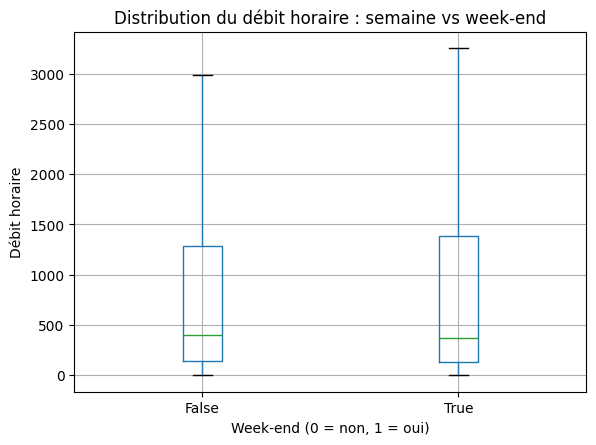

<Figure size 600x400 with 0 Axes>

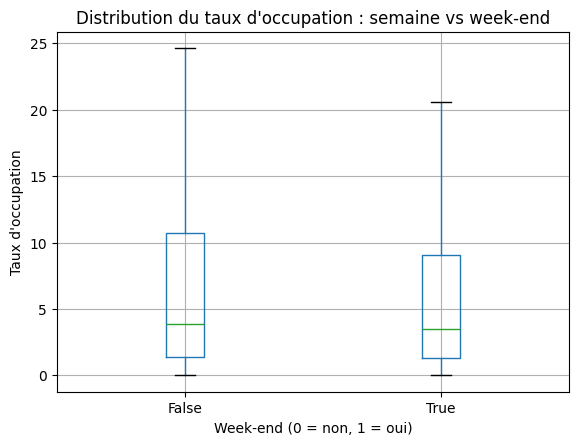

<Figure size 600x400 with 0 Axes>

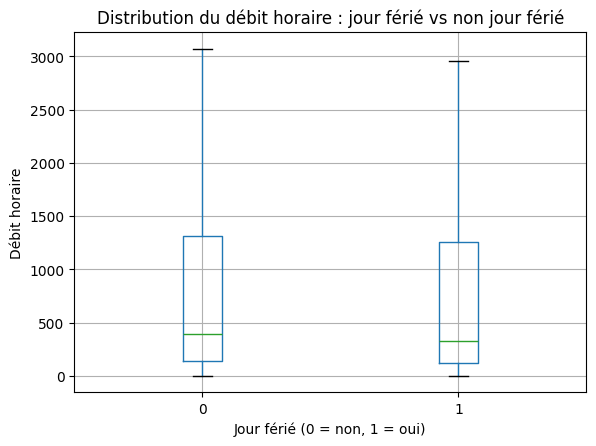

<Figure size 600x400 with 0 Axes>

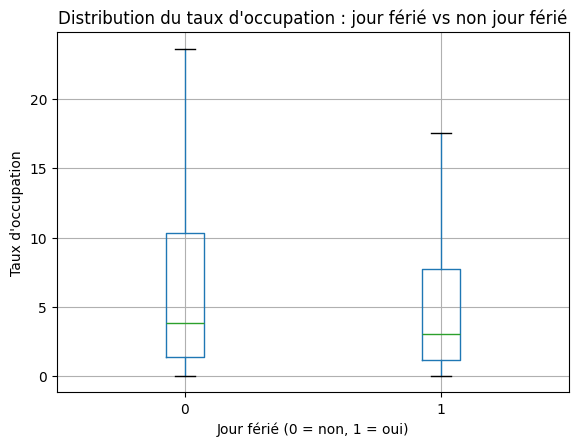

<Figure size 600x400 with 0 Axes>

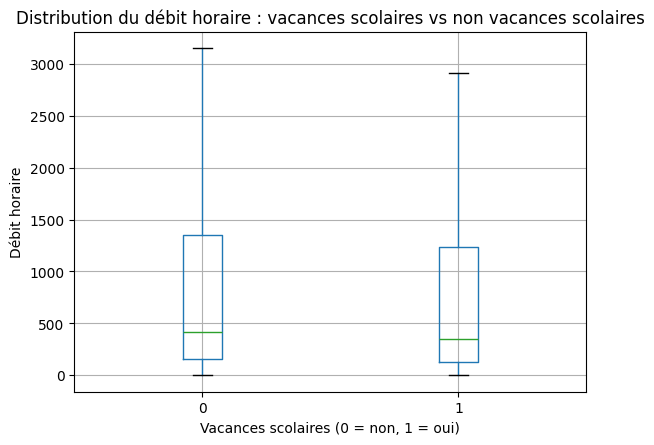

<Figure size 600x400 with 0 Axes>

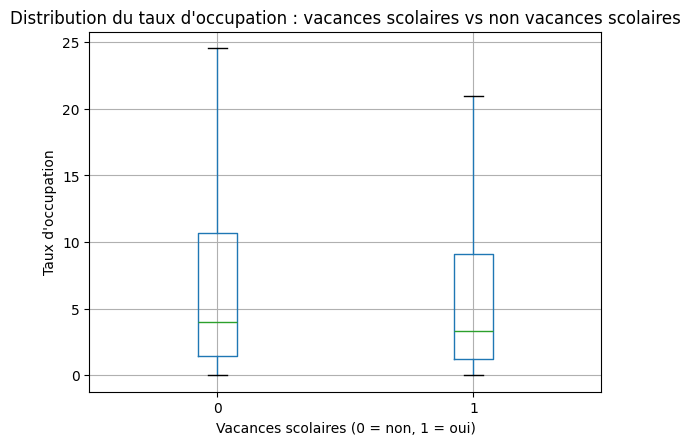

<Figure size 600x400 with 0 Axes>

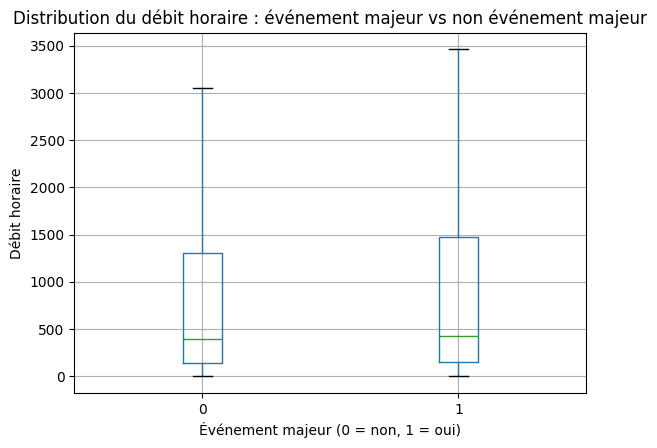

<Figure size 600x400 with 0 Axes>

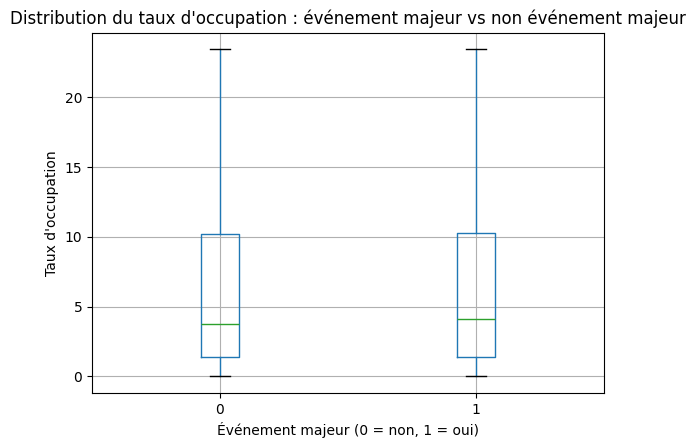

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_weekend',
    showfliers=False
)

plt.title('Distribution du débit horaire : semaine vs week-end')
plt.suptitle('')
plt.xlabel('Week-end (0 = non, 1 = oui)')
plt.ylabel('Débit horaire')
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_weekend',
    showfliers=False
)

plt.title("Distribution du taux d'occupation : semaine vs week-end")
plt.suptitle('')
plt.xlabel('Week-end (0 = non, 1 = oui)')
plt.ylabel("Taux d'occupation")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_jour_ferie',  
    showfliers=False
)   
plt.title('Distribution du débit horaire : jour férié vs non jour férié')
plt.suptitle('')
plt.xlabel('Jour férié (0 = non, 1 = oui)') 
plt.ylabel('Débit horaire')
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_jour_ferie',  
    showfliers=False
)   
plt.title("Distribution du taux d'occupation : jour férié vs non jour férié")
plt.suptitle('')
plt.xlabel('Jour férié (0 = non, 1 = oui)') 
plt.ylabel("Taux d'occupation")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_vacances_scolaires',   
    showfliers=False
)
plt.title('Distribution du débit horaire : vacances scolaires vs non vacances scolaires')   
plt.suptitle('')
plt.xlabel('Vacances scolaires (0 = non, 1 = oui)')
plt.ylabel('Débit horaire')
plt.show()  

plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_vacances_scolaires',   
    showfliers=False
)   
plt.title("Distribution du taux d'occupation : vacances scolaires vs non vacances scolaires")   
plt.suptitle('')    
plt.xlabel('Vacances scolaires (0 = non, 1 = oui)')
plt.ylabel("Taux d'occupation")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_evenement_majeur',
    showfliers=False
)
plt.title('Distribution du débit horaire : événement majeur vs non événement majeur')   
plt.suptitle('')
plt.xlabel('Événement majeur (0 = non, 1 = oui)')
plt.ylabel('Débit horaire')
plt.show()  
plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_evenement_majeur',
    showfliers=False
)
plt.title("Distribution du taux d'occupation : événement majeur vs non événement majeur")   
plt.suptitle('')    
plt.xlabel('Événement majeur (0 = non, 1 = oui)')
plt.ylabel("Taux d'occupation")
plt.show()  


<Figure size 800x500 with 0 Axes>

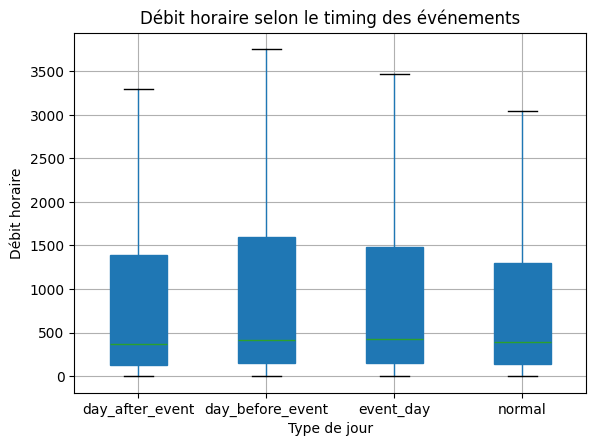

<Figure size 800x500 with 0 Axes>

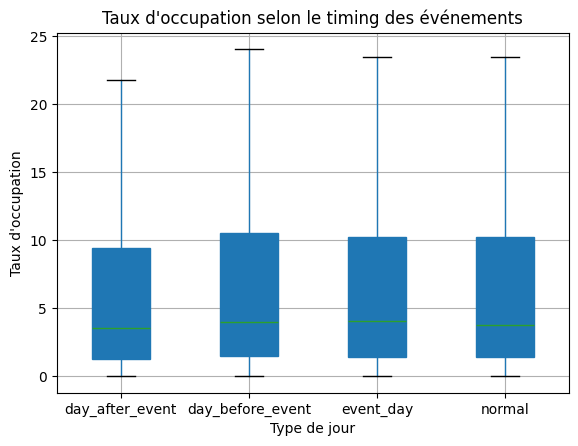

<Figure size 800x500 with 0 Axes>

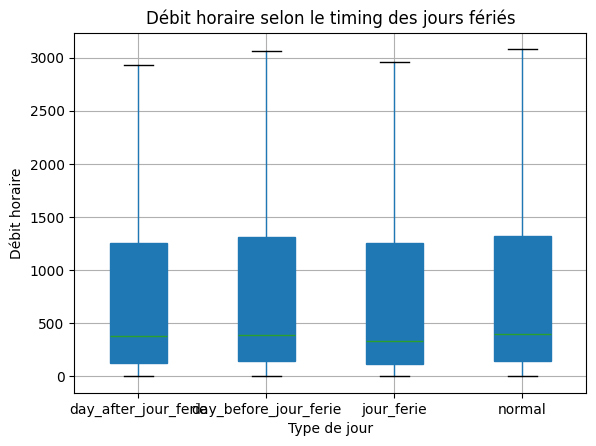

<Figure size 800x500 with 0 Axes>

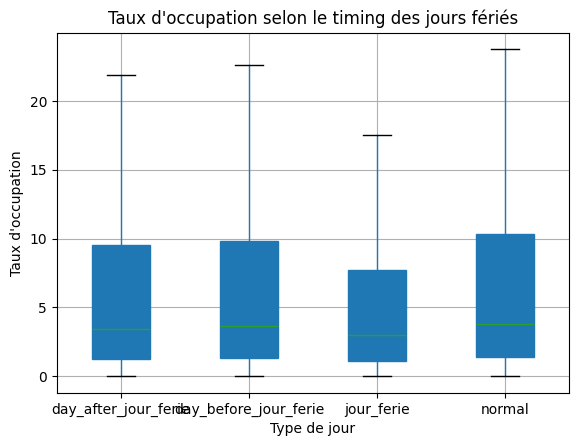

<Figure size 800x500 with 0 Axes>

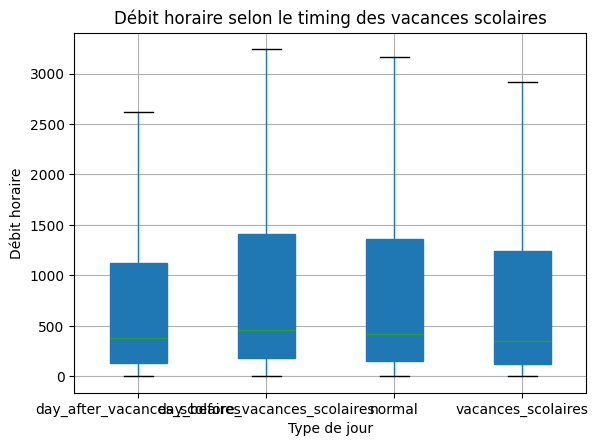

<Figure size 800x500 with 0 Axes>

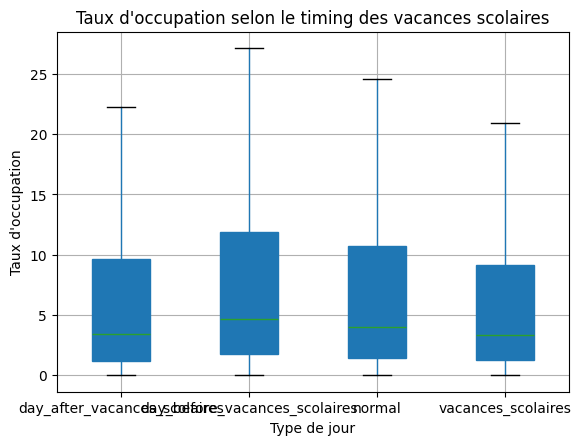

<Figure size 800x500 with 0 Axes>

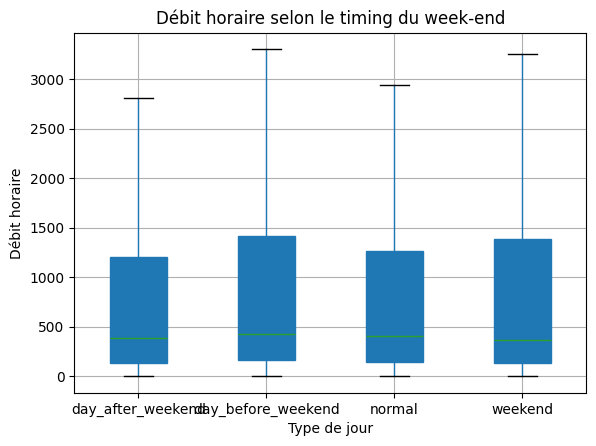

<Figure size 800x500 with 0 Axes>

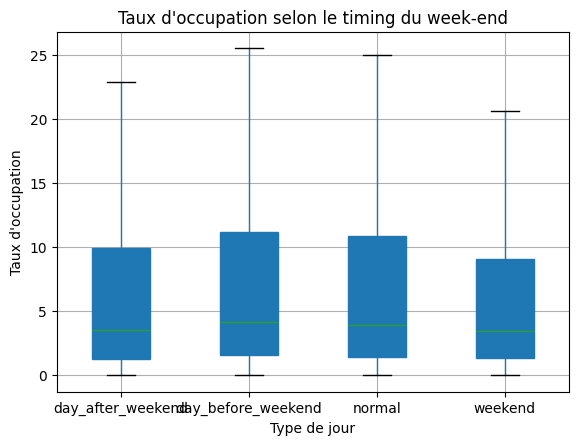

Script exécuté avec succès.


In [20]:
# 事件前后影响 Analyse de l'impact avant et après les événements
df['event_timing'] = 'normal'  # 默认非事件
df.loc[df['est_evenement_majeur'] == 1, 'event_timing'] = 'event_day'
df.loc[df['est_evenement_majeur_day_before'] == 1, 'event_timing'] = 'day_before_event'
df.loc[df['est_evenement_majeur_day_after'] == 1, 'event_timing'] = 'day_after_event'
summary_event_timing = (
    df
    .groupby('event_timing')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='event_timing',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)
plt.title("Débit horaire selon le timing des événements")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel('Débit horaire')
plt.show()

plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='event_timing',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing des événements")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel("Taux d'occupation")
plt.show()

# 公共假日前后影响 Analyse de l'impact avant et après les jours fériés
df['jour_ferie_timing'] = 'normal'  # 默认非事件
df.loc[df['est_jour_ferie'] == 1, 'jour_ferie_timing'] = 'jour_ferie'
df.loc[df['est_jour_ferie_day_before'] == 1, 'jour_ferie_timing'] = 'day_before_jour_ferie'
df.loc[df['est_jour_ferie_day_after'] == 1, 'jour_ferie_timing'] = 'day_after_jour_ferie'
summary_jour_ferie_timing = (
    df.groupby('jour_ferie_timing')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='jour_ferie_timing',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)   
plt.title("Débit horaire selon le timing des jours fériés")
plt.suptitle('')
plt.xlabel('Type de jour')  
plt.ylabel('Débit horaire')
plt.show()
plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='jour_ferie_timing',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing des jours fériés")
plt.suptitle('')
plt.xlabel('Type de jour')  
plt.ylabel("Taux d'occupation")
plt.show()

# 学生假日前后影响 Analyse de l'impact avant et après les vacances scolaires
df['vacance_timing'] = 'normal'  # 默认非事件
df.loc[df['est_vacances_scolaires'] == 1, 'vacance_timing'] = 'vacances_scolaires'
df.loc[df['est_vacances_scolaires_day_before'] == 1, 'vacance_timing'] = 'day_before_vacances_scolaires'
df.loc[df['est_vacances_scolaires_day_after'] == 1, 'vacance_timing'] = 'day_after_vacances_scolaires'
summary_vacance_timing = ( 
    df.groupby('vacance_timing')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='vacance_timing',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)
plt.title("Débit horaire selon le timing des vacances scolaires")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel('Débit horaire')
plt.show()
plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='vacance_timing',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing des vacances scolaires")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel("Taux d'occupation")
plt.show()

# 周末前后影响 Analyse de l'impact avant et après les week-ends
df['weekend_time'] = 'normal'  # 默认非事件
df.loc[df['est_weekend'] == 1, 'weekend_time'] = 'weekend'
df.loc[df['est_weekend_day_before'] == 1, 'weekend_time'] = 'day_before_weekend'
df.loc[df['est_weekend_day_after'] == 1, 'weekend_time'] = 'day_after_weekend'
summary_weekend_time = (   
    df.groupby('weekend_time')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='weekend_time',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)
plt.title("Débit horaire selon le timing du week-end")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel('Débit horaire')
plt.show()
plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='weekend_time',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing du week-end")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel("Taux d'occupation")
plt.show()
print("Script exécuté avec succès.")

In [21]:
summary_weekend_time

,weekend_time,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,day_after_weekend,70389,970.004843,382.0,131.0,1203.0,70389,8.435371,3.517220,1.25000,9.90
1,day_before_weekend,72480,1049.948606,426.0,159.0,1418.0,72480,9.377828,4.159725,1.55000,11.15
2,normal,220063,1004.000795,406.0,148.0,1267.0,220063,9.233839,3.950000,1.41167,10.85
3,weekend,146097,976.613319,368.0,136.0,1383.0,146097,7.809491,3.481110,1.33722,9.05


In [22]:
summary_event_timing

,event_timing,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,day_after_event,4788,968.599206,372.0,125.0,1394.00,4788,8.470847,3.530835,1.251665,9.45611
1,day_before_event,4830,1049.044720,421.0,156.0,1596.75,4830,8.933943,3.976390,1.464030,10.50000
2,event_day,21033,1019.578282,432.0,157.0,1480.00,21033,8.920707,4.077220,1.418890,10.23945
3,normal,478378,996.810722,394.0,142.0,1303.00,478378,8.727603,3.757780,1.382230,10.20000


In [23]:
summary_vacance_timing

,vacance_timing,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,day_after_vacances_scolaires,7964,958.706554,374.0,129.0,1125.5,7964,8.181000,3.38472,1.22042,9.65000
1,day_before_vacances_scolaires,7305,1085.852567,456.0,180.0,1407.0,7305,9.942273,4.63722,1.72611,11.90000
2,normal,322951,1025.794925,417.0,153.0,1357.0,322951,9.136047,4.02056,1.46056,10.70000
3,vacances_scolaires,170809,943.468201,353.0,125.0,1240.0,170809,7.951304,3.35000,1.25000,9.12333


In [24]:
summary_jour_ferie_timing

,jour_ferie_timing,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,day_after_jour_ferie,17024,960.208000,376.0,129.0,1251.25,17024,8.314856,3.421115,1.222228,9.50
1,day_before_jour_ferie,16644,992.844388,384.5,141.0,1311.25,16644,8.438877,3.679165,1.343330,9.85
2,jour_ferie,16624,903.362488,330.0,118.0,1253.00,16624,6.658104,2.990000,1.123193,7.70
3,normal,458737,1002.998816,399.0,144.0,1319.00,458737,8.836738,3.822220,1.400000,10.35


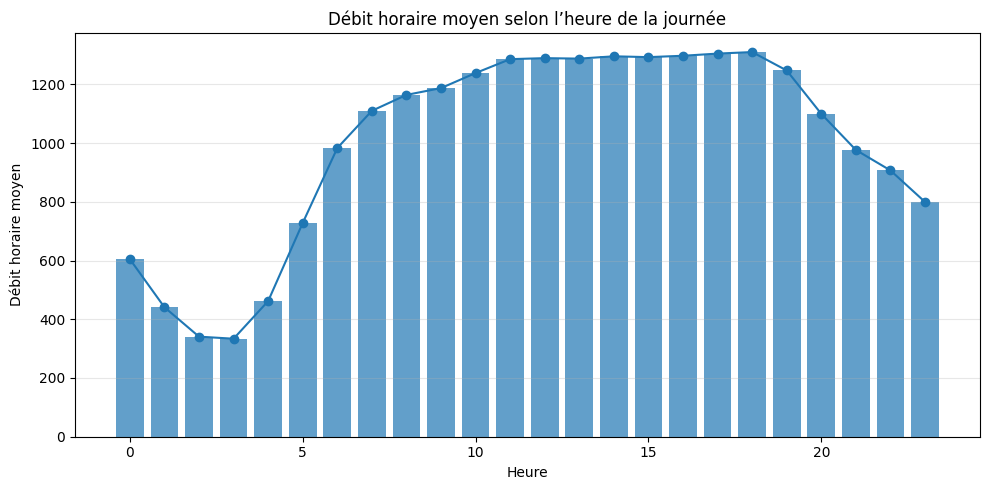

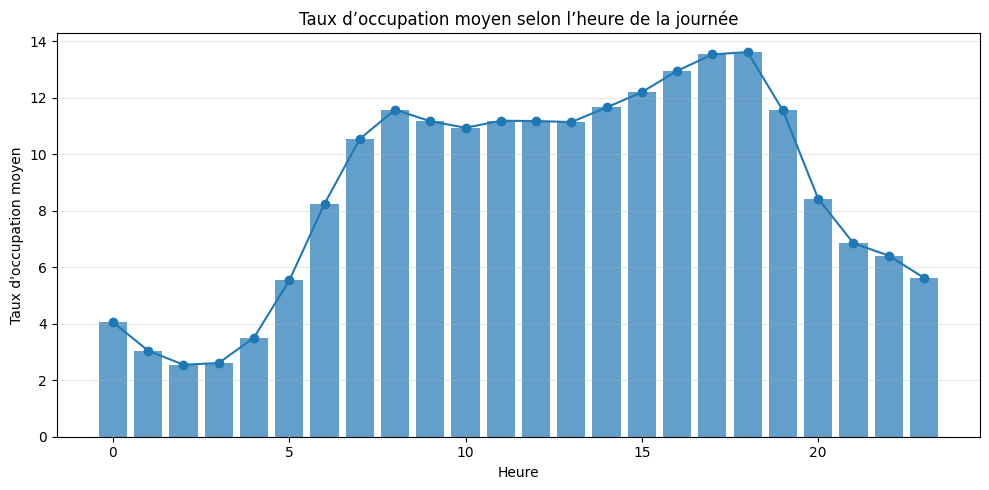

In [25]:
import matplotlib.pyplot as plt

def bar_line_plot(x, y, xlabel, ylabel, title, xticklabels=None):
    plt.figure(figsize=(10,5))

    # bar
    plt.bar(x, y, alpha=0.7)

    # line (same values)
    plt.plot(x, y, marker='o')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    if xticklabels is not None:
        plt.xticks(x, xticklabels)

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

df['heure'] = df['Date et heure de comptage'].dt.hour

hourly_mean = (
    df.groupby('heure')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
)

bar_line_plot(
    x=hourly_mean.index,
    y=hourly_mean['debit_mean'],
    xlabel="Heure",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon l’heure de la journée"
)

bar_line_plot(
    x=hourly_mean.index,
    y=hourly_mean['occupation_mean'],
    xlabel="Heure",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon l’heure de la journée"
)


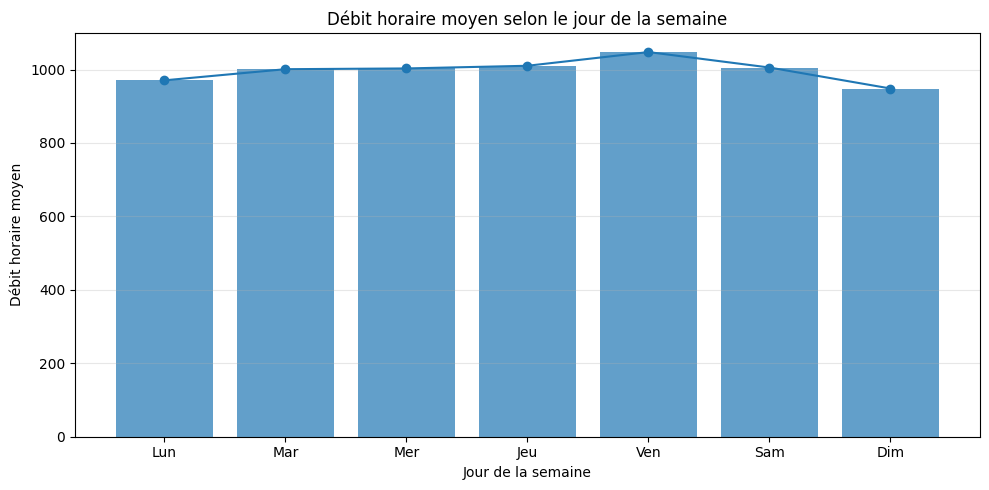

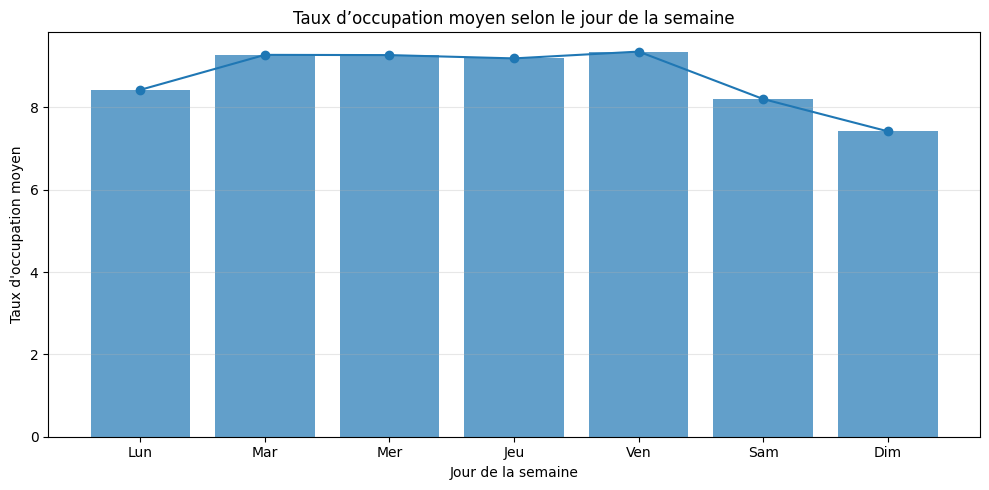

In [26]:
weekday_mean = (
    df.groupby('weekday')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
)

weekday_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
bar_line_plot(
    x=weekday_mean.index,
    y=weekday_mean['debit_mean'],
    xlabel="Jour de la semaine",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon le jour de la semaine",
    xticklabels=weekday_labels
)
bar_line_plot(
    x=weekday_mean.index,
    y=weekday_mean['occupation_mean'],
    xlabel="Jour de la semaine",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon le jour de la semaine",
    xticklabels=weekday_labels
)

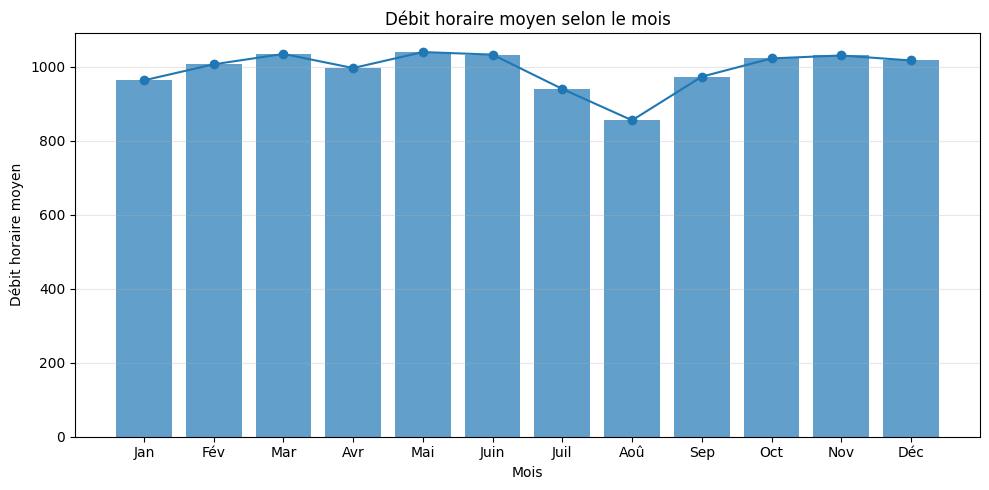

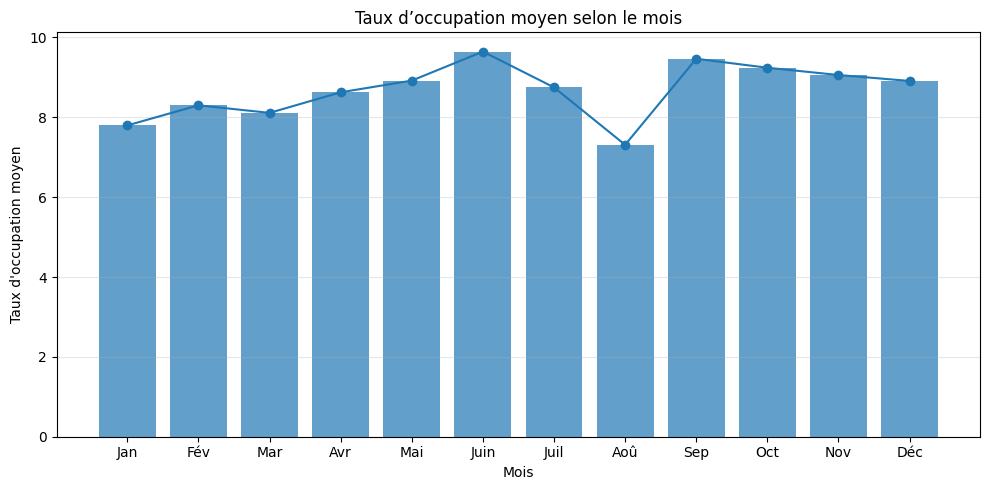

In [27]:
monthly_mean = (
    df.groupby('mois')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
)
month_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
bar_line_plot(
    x=monthly_mean.index,
    y=monthly_mean['debit_mean'],
    xlabel="Mois",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon le mois",
    xticklabels=month_labels
)
bar_line_plot(
    x=monthly_mean.index,
    y=monthly_mean['occupation_mean'],
    xlabel="Mois",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon le mois",
    xticklabels=month_labels
)

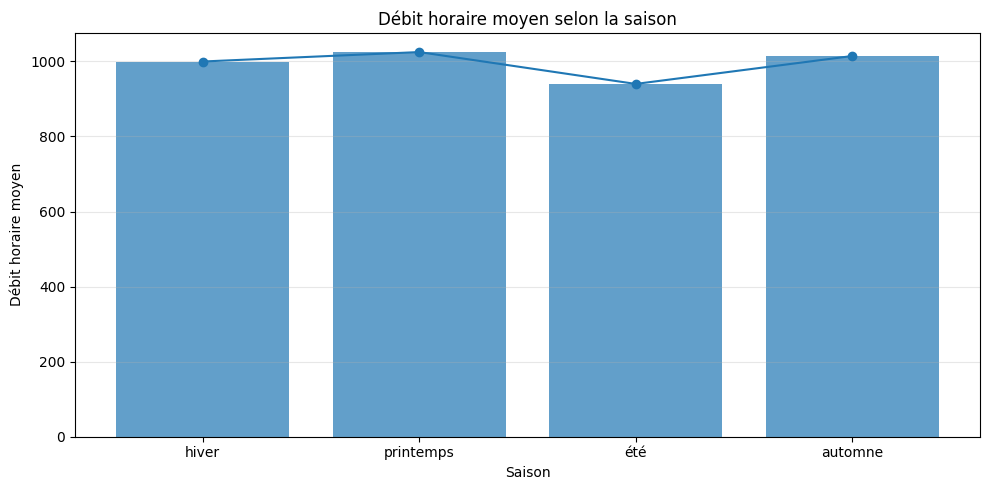

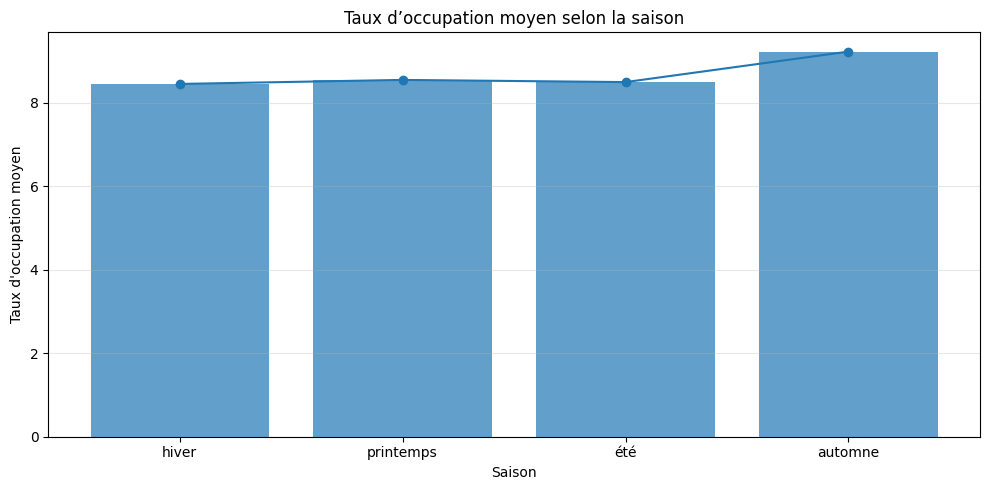

In [28]:
season_order = ['hiver', 'printemps', 'été', 'automne']

season_mean = (
    df.groupby('saison')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
      .reindex(season_order)
)
bar_line_plot(
    x=season_mean.index,
    y=season_mean['debit_mean'],
    xlabel="Saison",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon la saison"
)
bar_line_plot(
    x=season_mean.index,
    y=season_mean['occupation_mean'],
    xlabel="Saison",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon la saison"
)

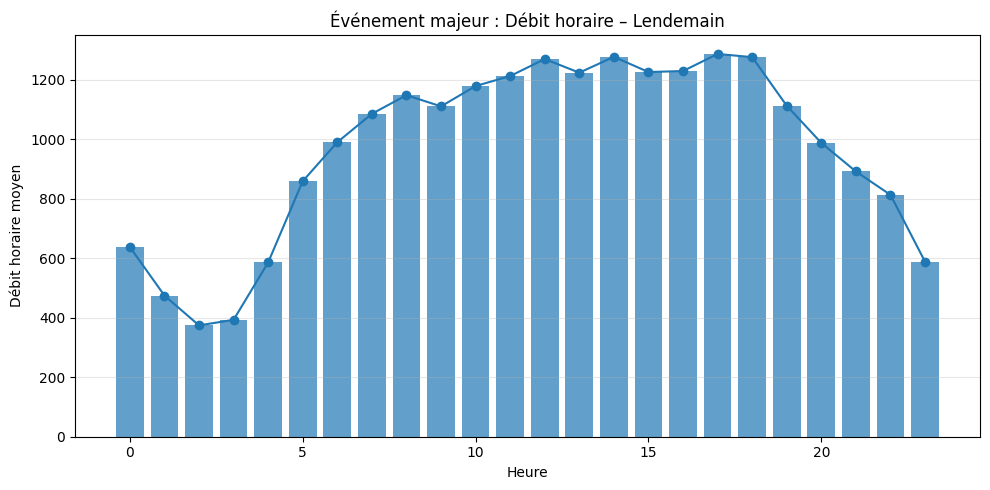

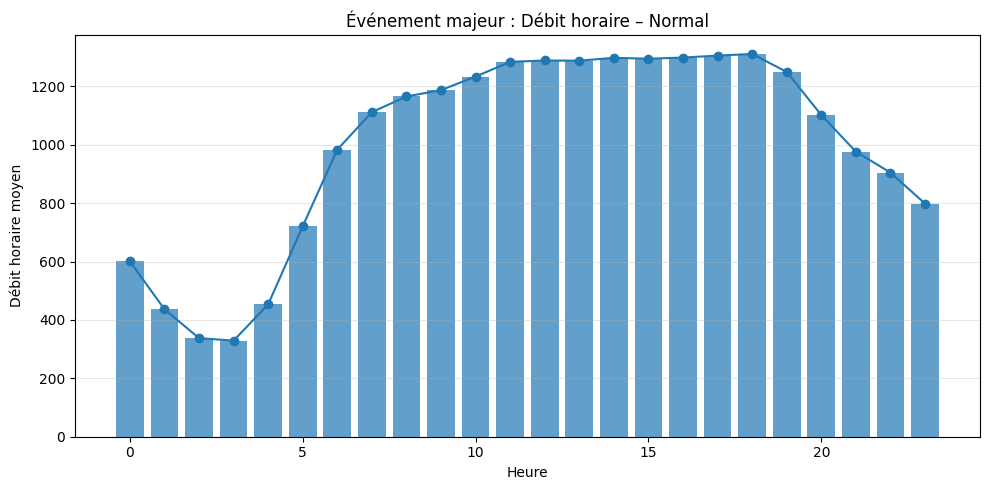

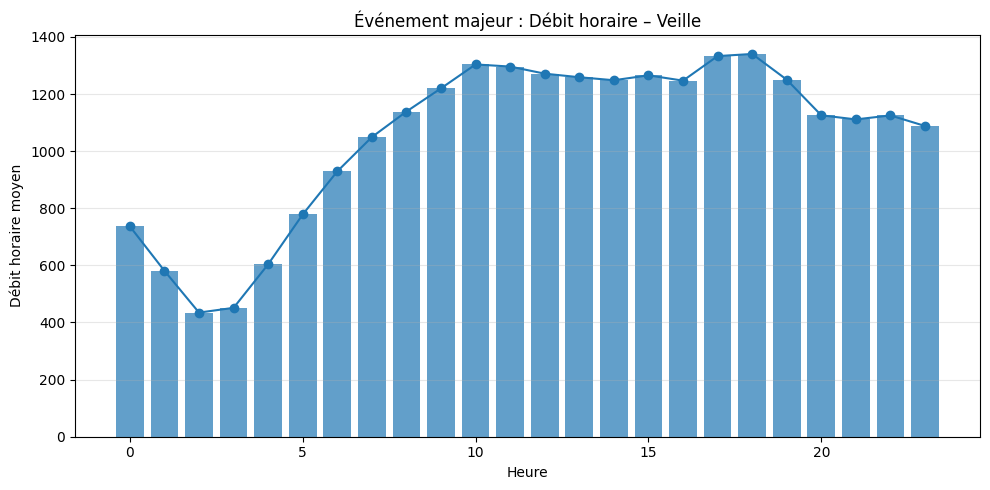

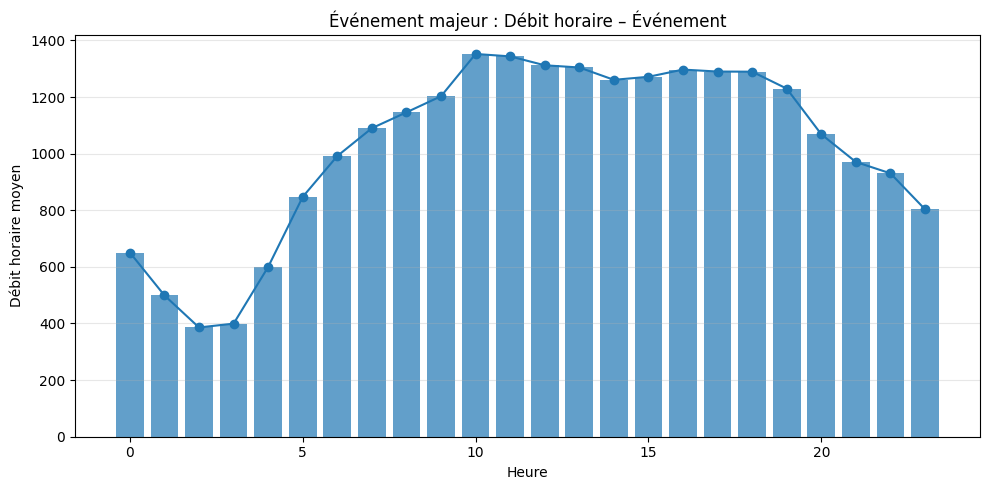

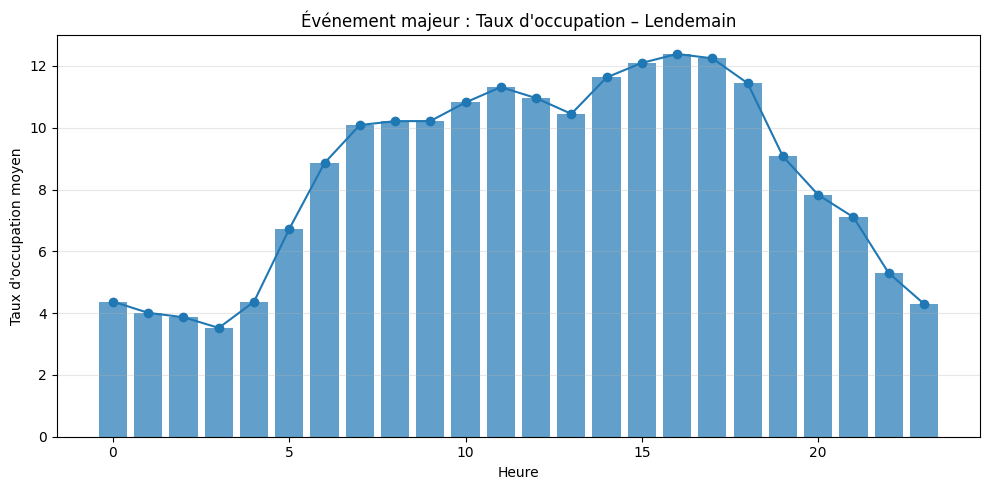

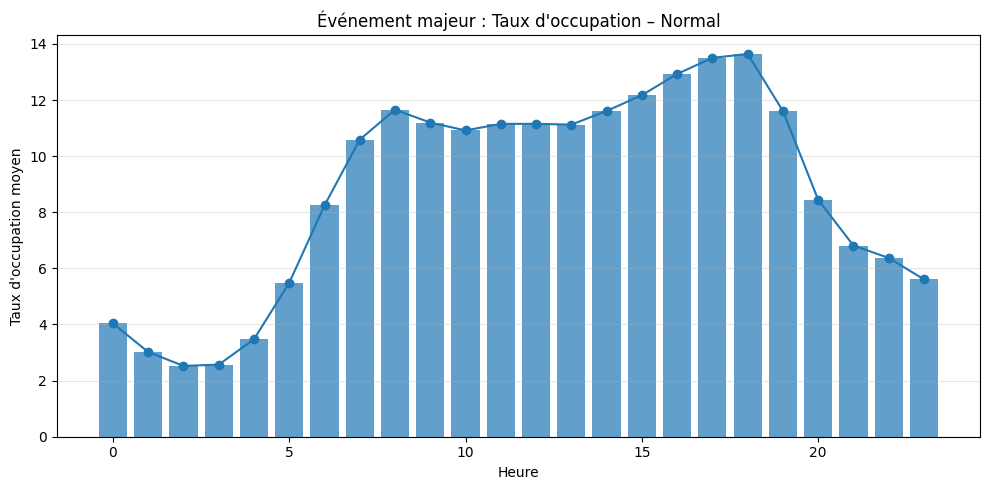

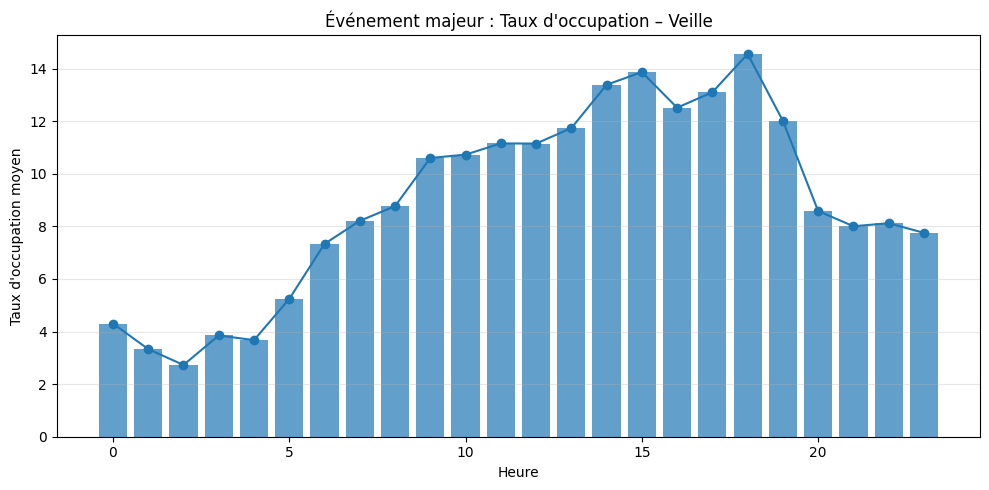

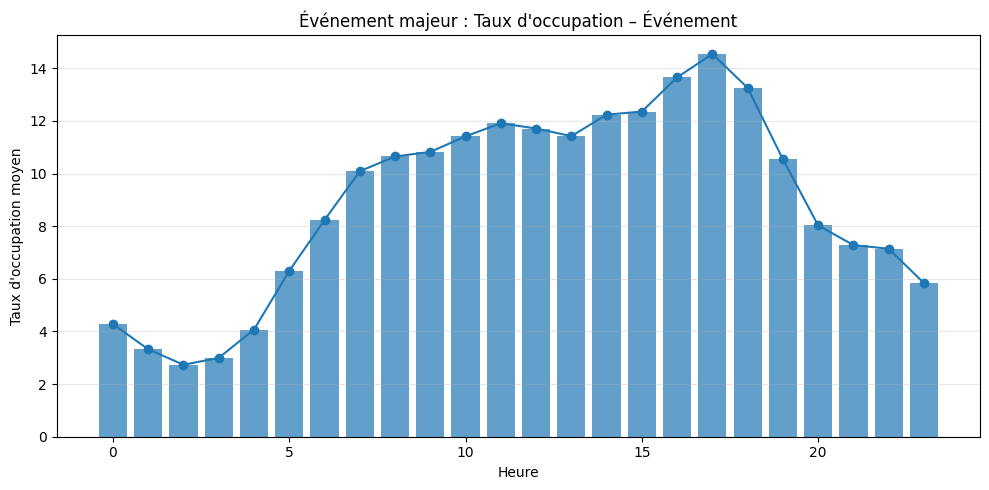

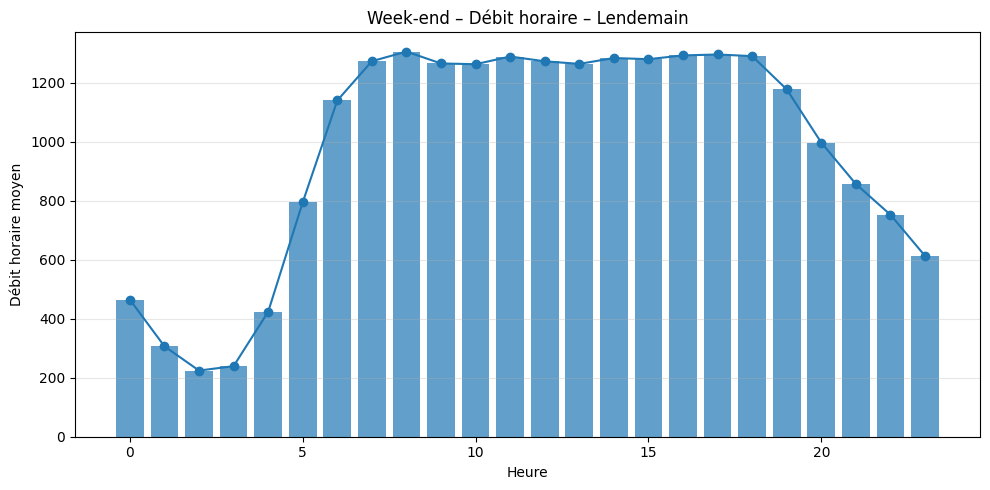

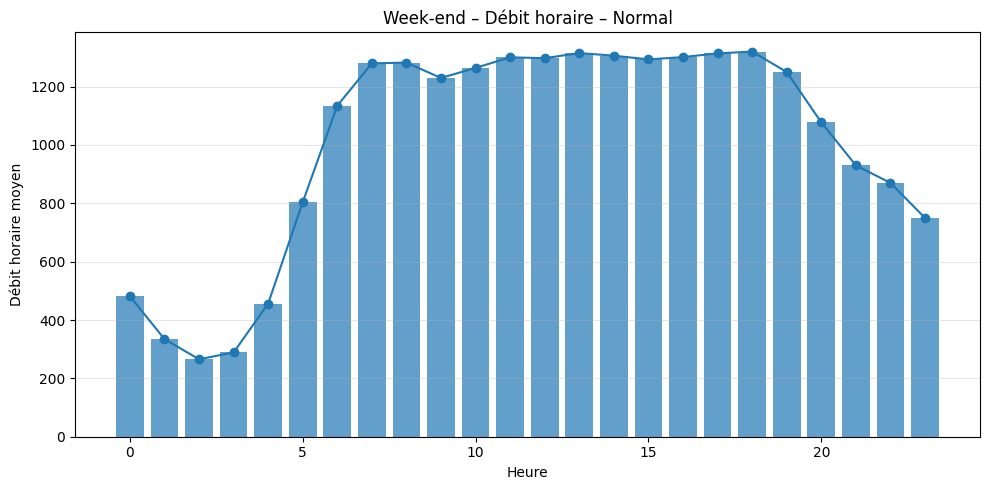

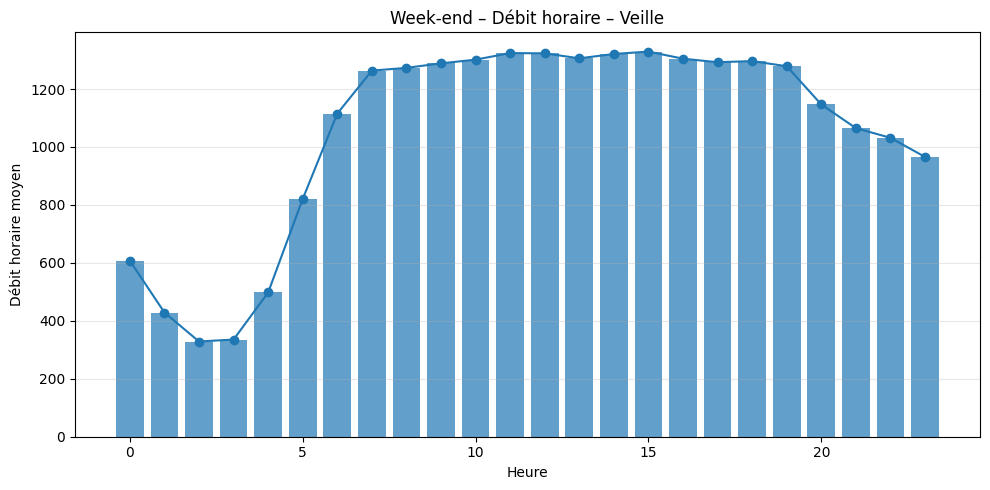

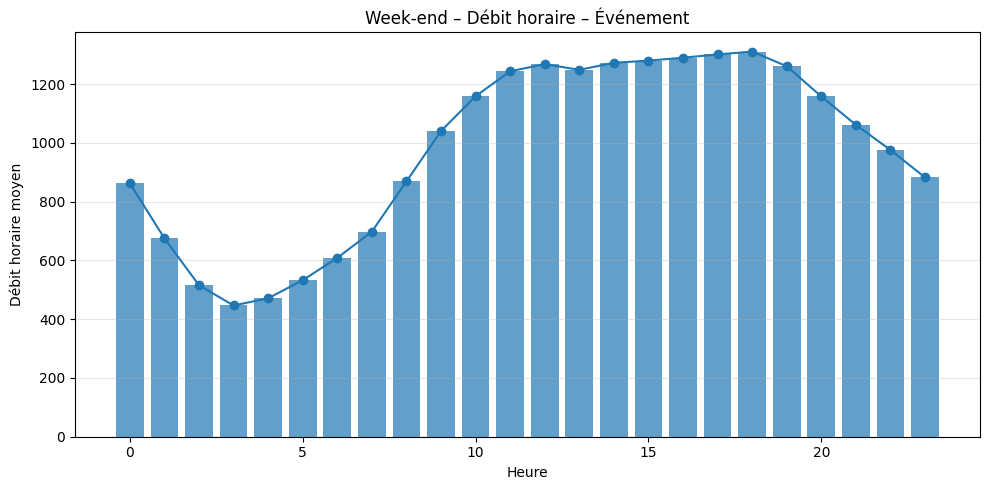

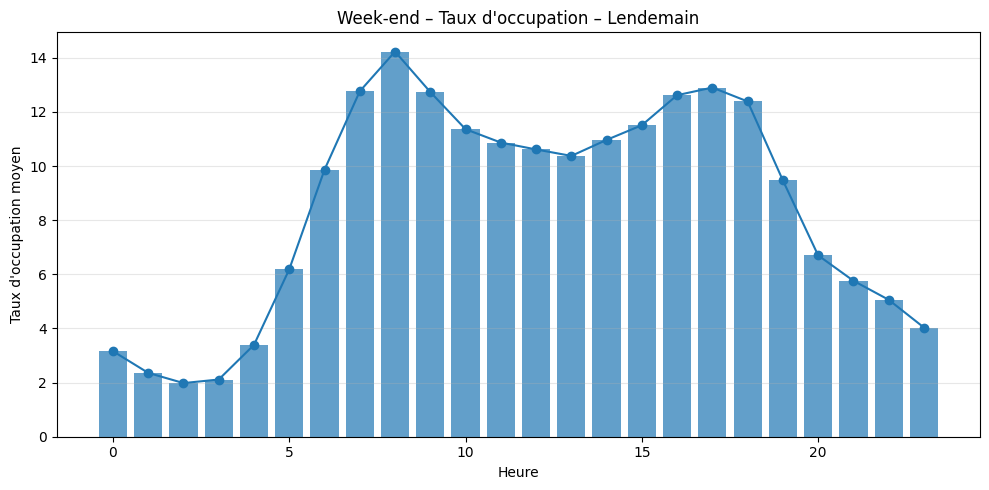

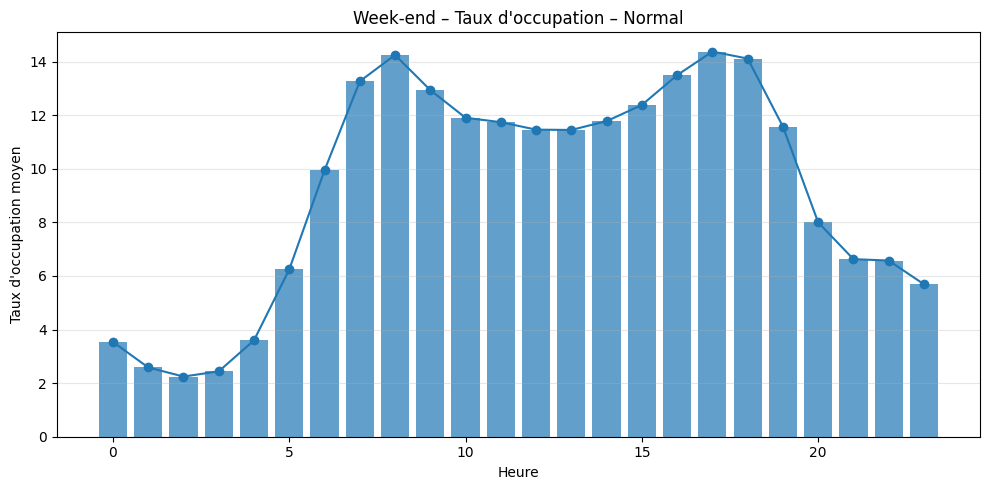

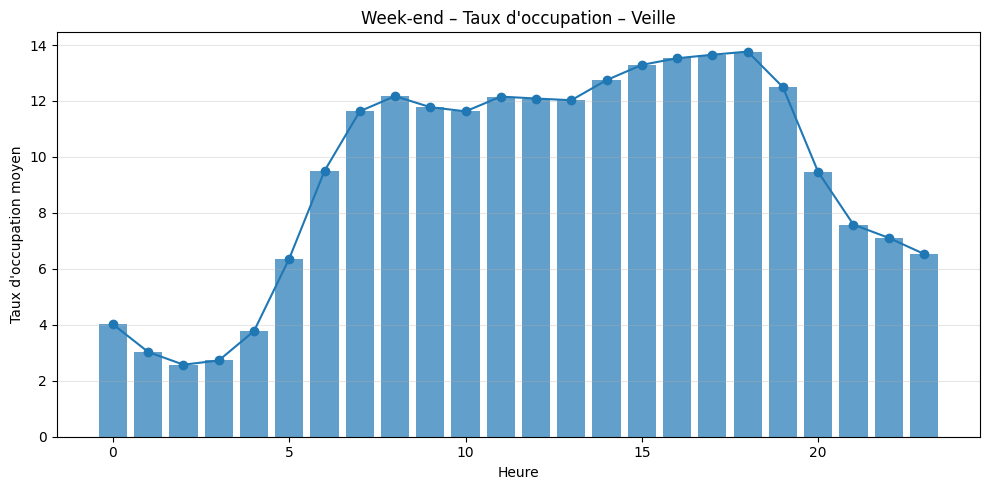

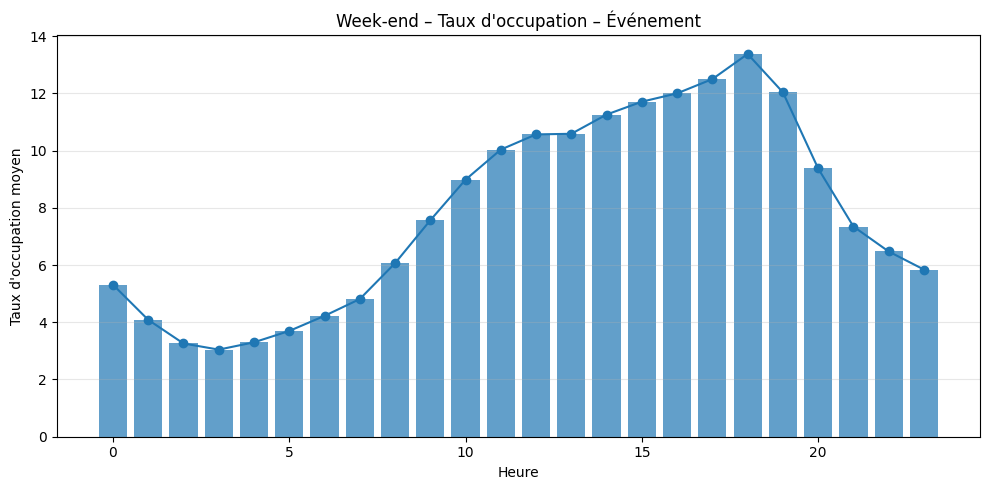

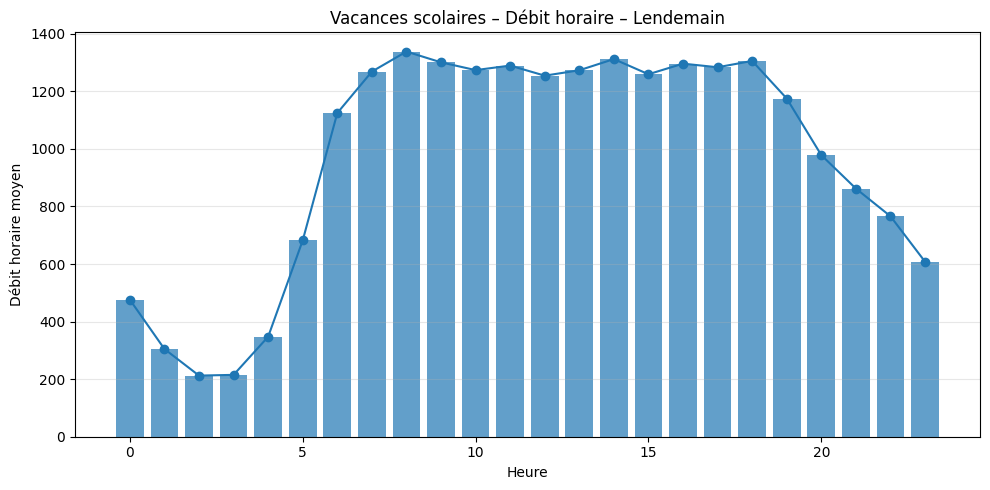

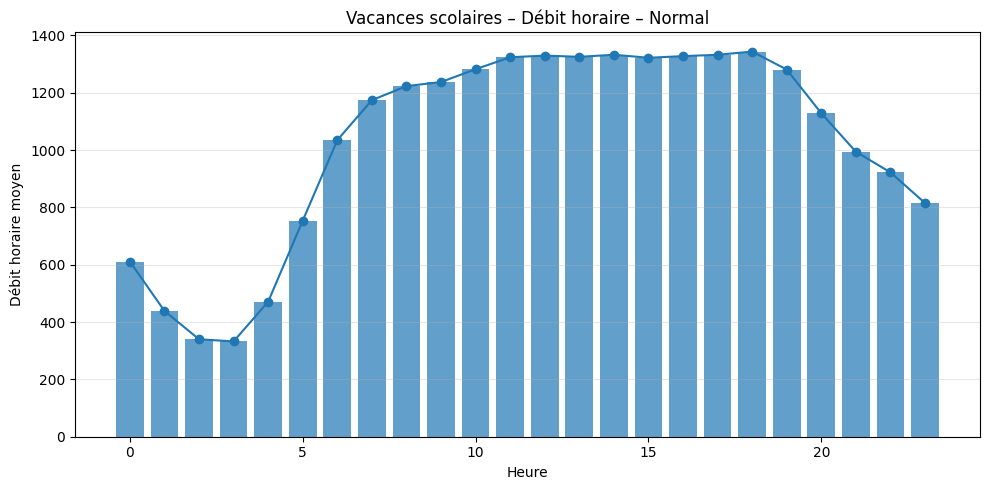

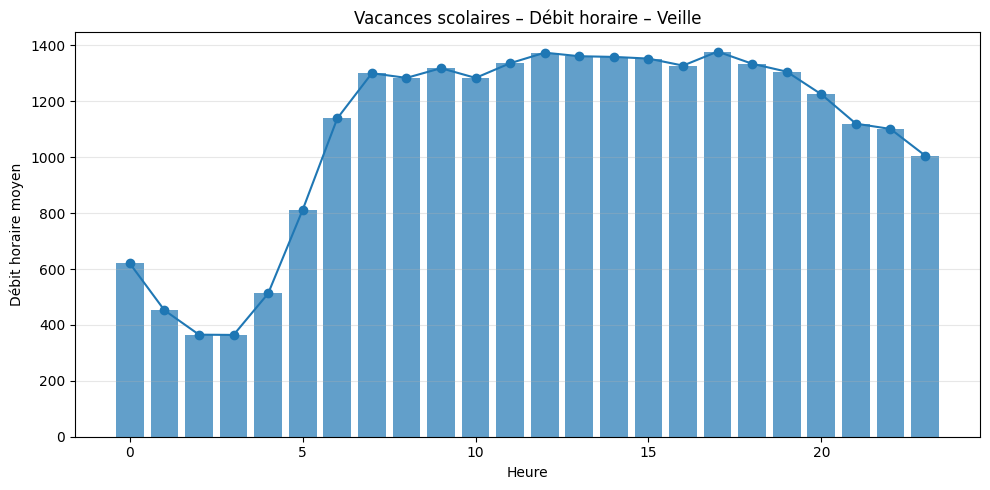

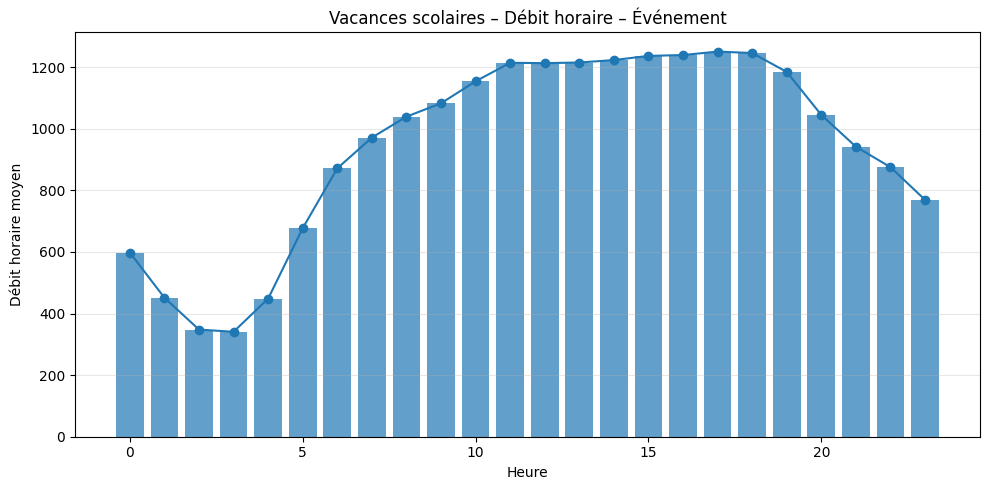

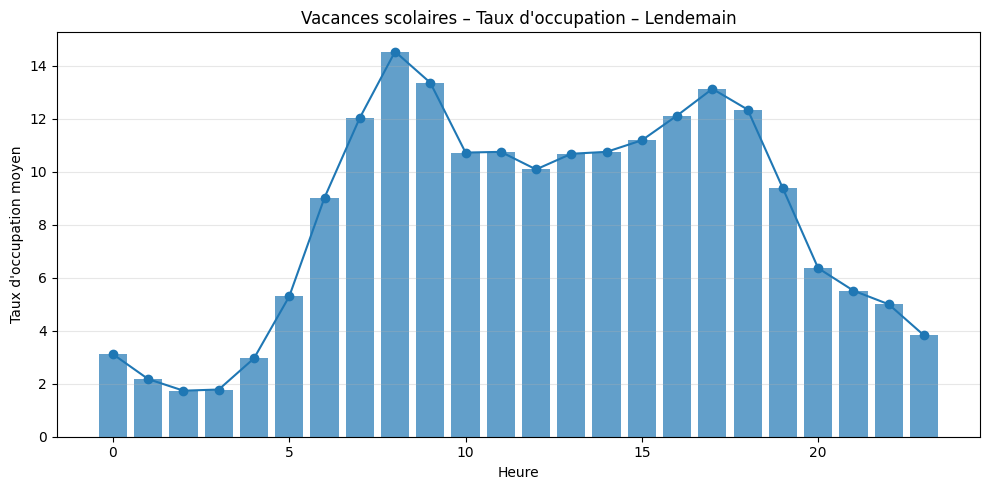

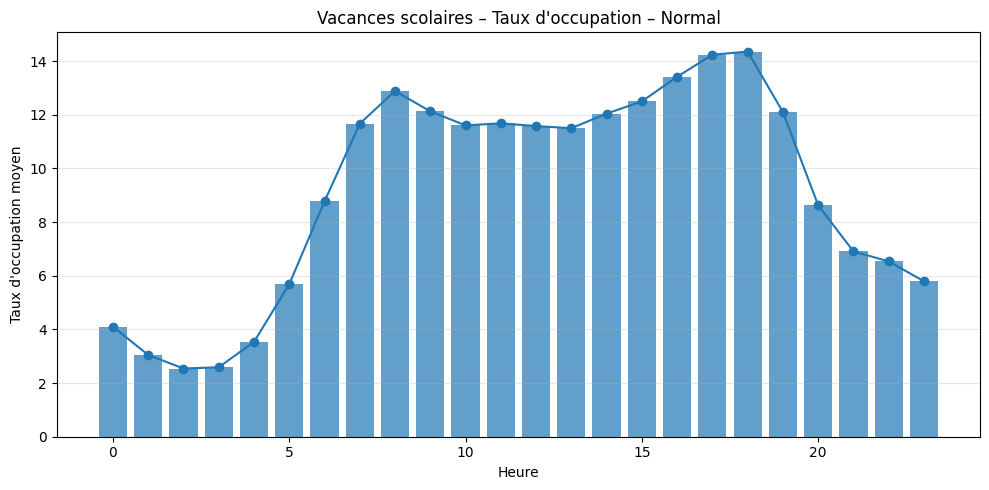

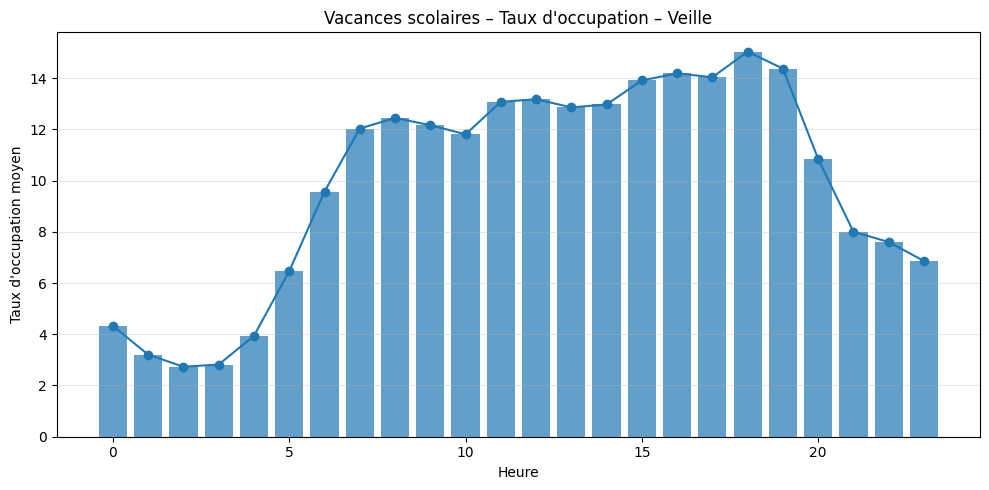

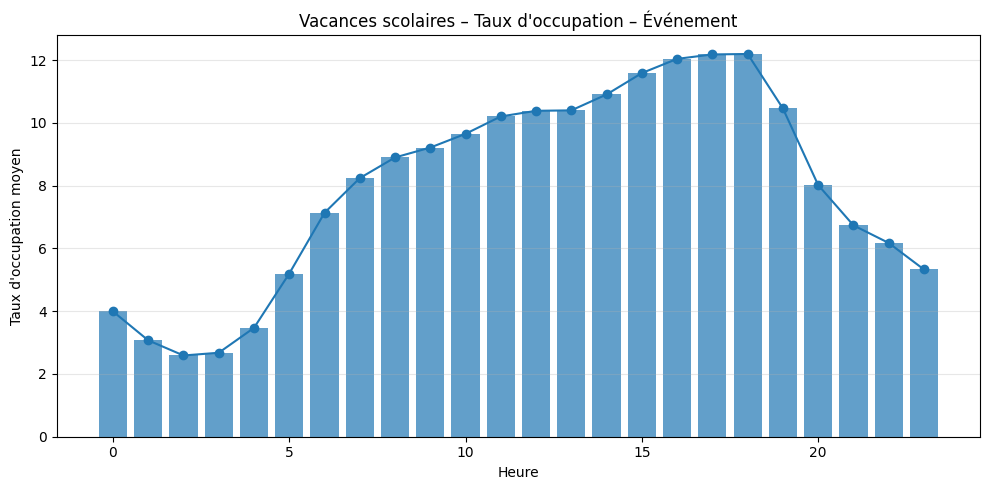

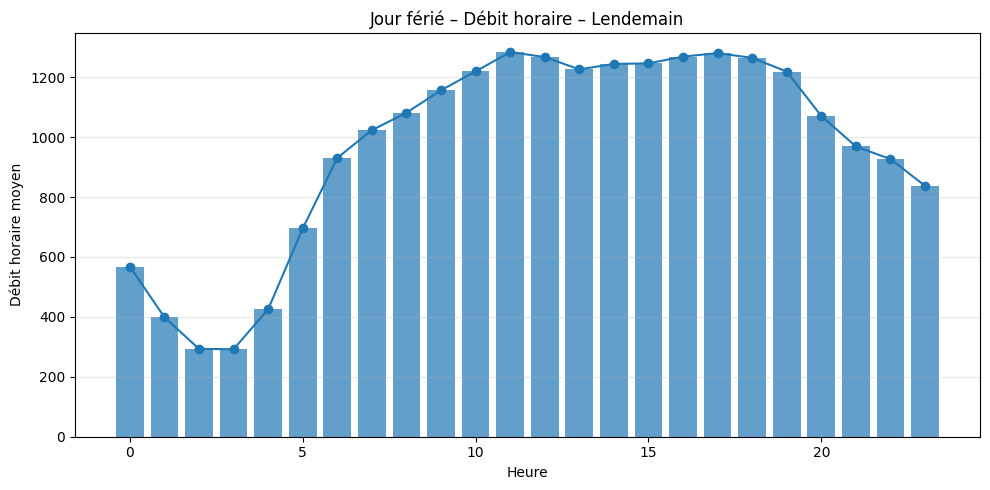

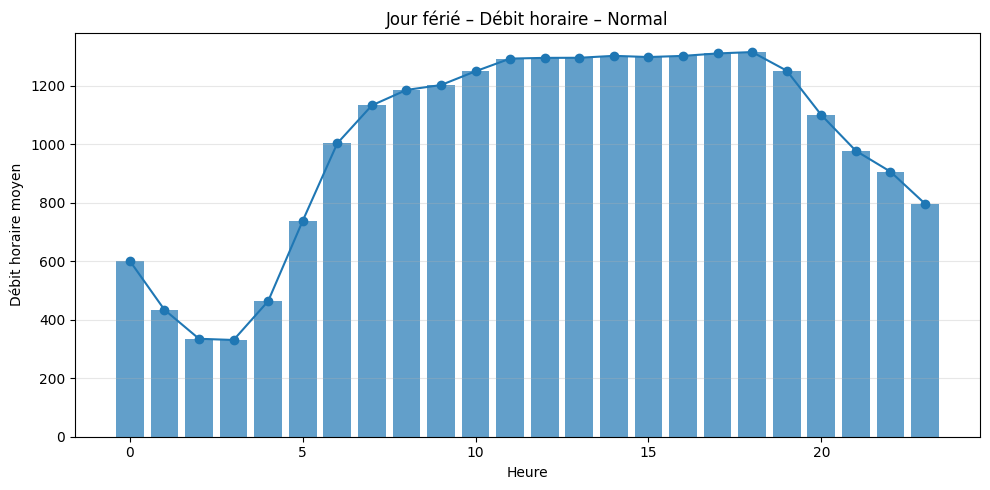

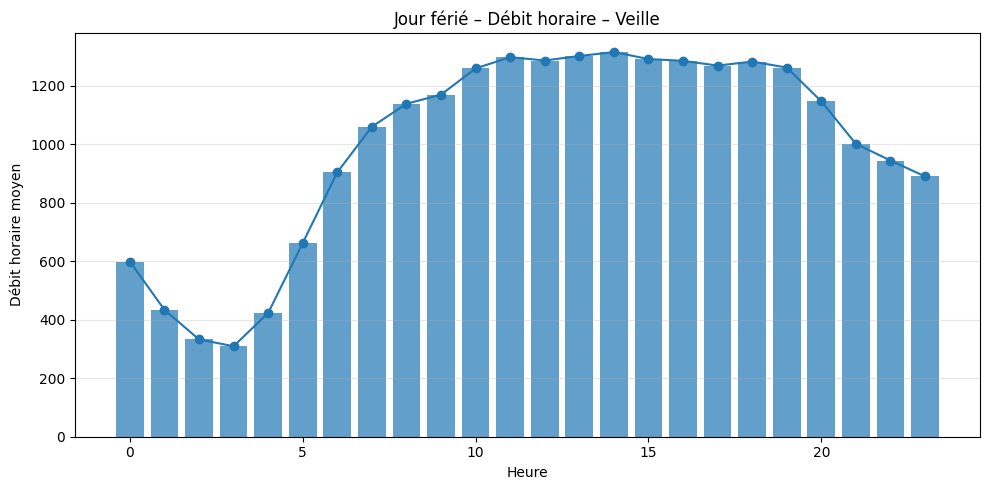

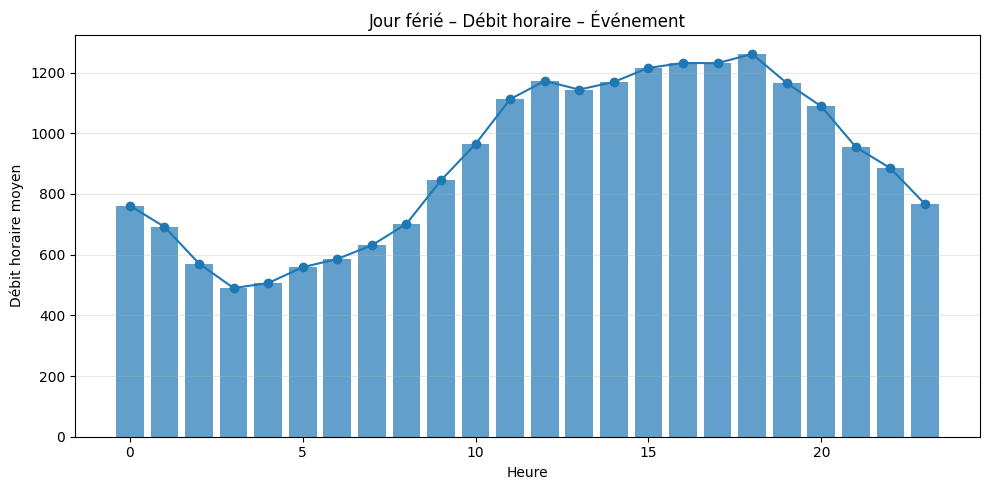

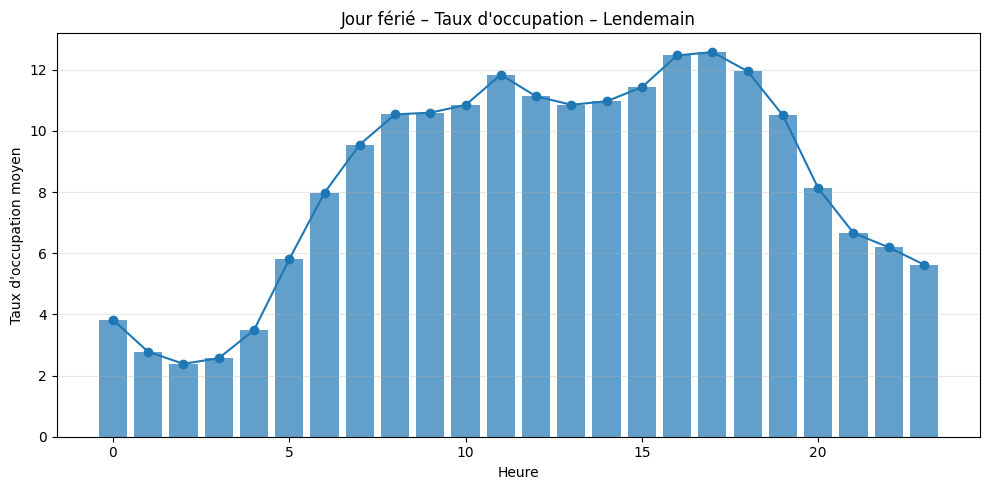

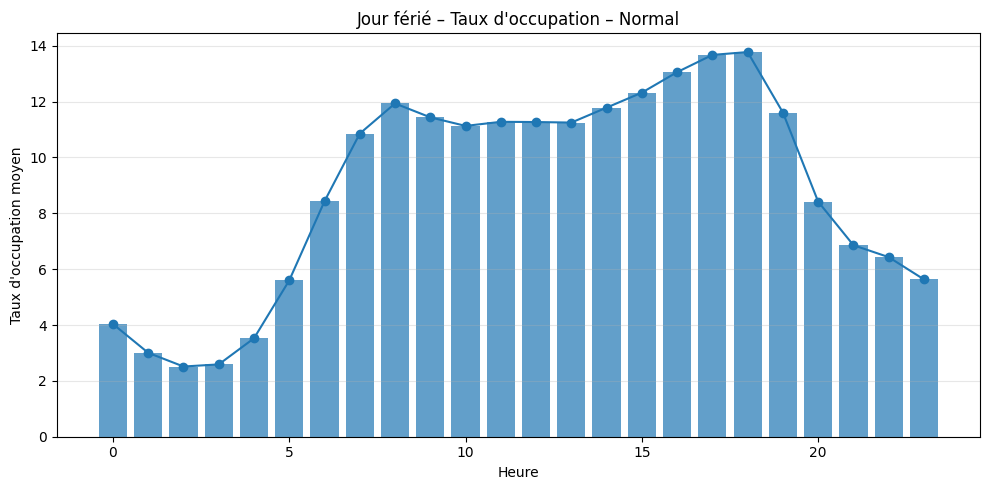

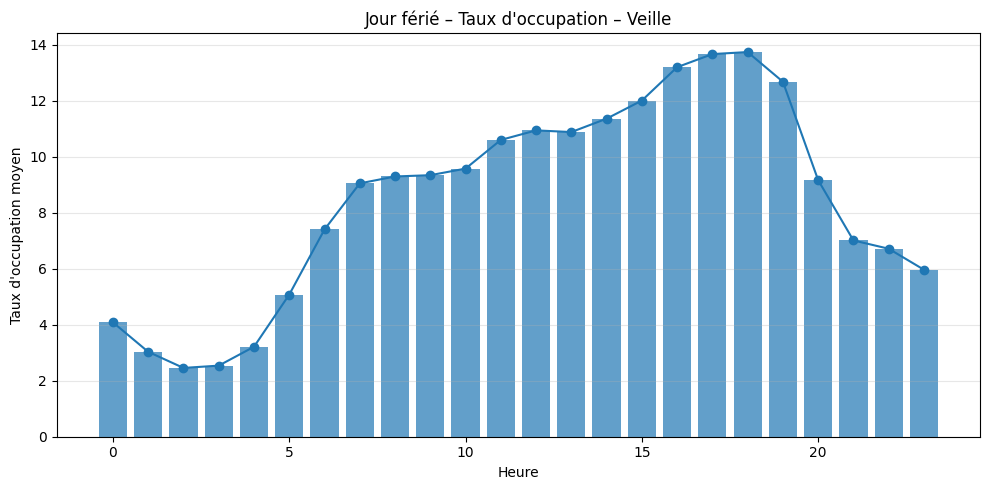

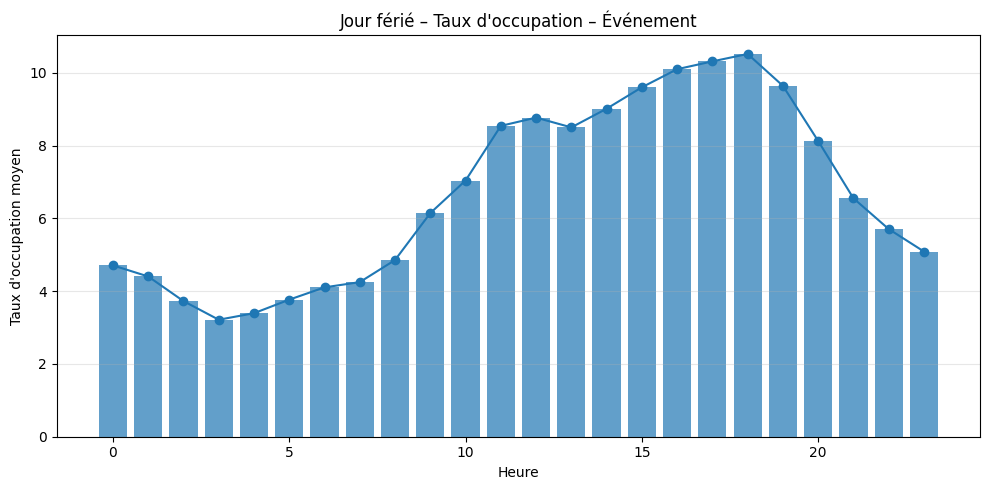

In [29]:
def plot_event_hourly_profile(
    df,
    event_prefix,
    value_col,
    title_prefix=""
):
    """
    df : DataFrame
    event_prefix : str, e.g. 'est_weekend'
    value_col : 'Débit horaire' or "Taux d'occupation"
    """

    df_tmp = df.copy()

    # 统一 phase
    phase_col = f'phase_{event_prefix}'
    df_tmp[phase_col] = 'Normal'

    df_tmp.loc[df_tmp[f'{event_prefix}_day_before'] == 1, phase_col] = 'Veille'
    df_tmp.loc[df_tmp[event_prefix] == 1, phase_col] = 'Événement'
    df_tmp.loc[df_tmp[f'{event_prefix}_day_after'] == 1, phase_col] = 'Lendemain'

    # 只保留有数据的 phase
    hourly_mean = (
        df_tmp
        .groupby(['heure', phase_col])[value_col]
        .mean()
        .unstack()
        .dropna(axis=1, how='all')
    )

    # 绘图
    for phase in hourly_mean.columns:
        bar_line_plot(
            x=hourly_mean.index,
            y=hourly_mean[phase],
            xlabel="Heure",
            ylabel=f"{value_col} moyen",
            title=f"{title_prefix}{value_col} – {phase}"
        )
plot_event_hourly_profile(
    df,
    event_prefix='est_evenement_majeur',
    value_col='Débit horaire', 
    title_prefix="Événement majeur : "
)
plot_event_hourly_profile(
    df,
    event_prefix='est_evenement_majeur',
    value_col="Taux d'occupation", 
    title_prefix="Événement majeur : "  
)

plot_event_hourly_profile(
    df,
    event_prefix='est_weekend',
    value_col='Débit horaire',
    title_prefix='Week-end – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_weekend',
    value_col="Taux d'occupation",
    title_prefix='Week-end – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_vacances_scolaires',
    value_col='Débit horaire',
    title_prefix='Vacances scolaires – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_vacances_scolaires',
    value_col="Taux d'occupation",
    title_prefix='Vacances scolaires – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_jour_ferie',
    value_col='Débit horaire',
    title_prefix='Jour férié – '
)   
plot_event_hourly_profile(
    df,
    event_prefix='est_jour_ferie',
    value_col="Taux d'occupation",
    title_prefix='Jour férié – '
)